In [8]:

!pip install ultralytics roboflow supervision matplotlib opencv-python-headless -q

import os
import yaml
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

from ultralytics import YOLO
import supervision as sv
import cv2
from IPython.display import display, Image

print(" All libraries installed and imported successfully!")

 All libraries installed and imported successfully!


In [9]:

from ultralytics.data.utils import check_det_dataset

dataset_info = check_det_dataset("coco128.yaml")

print("COCO128 Dataset loaded successfully!")
print(f" Dataset path: {dataset_info['path']}")
print(f"  Number of classes: {len(dataset_info['names'])}")
print(f" Sample classes: {list(dataset_info['names'].values())[:10]} ...")

COCO128 Dataset loaded successfully!
 Dataset path: /content/datasets/coco128
  Number of classes: 80
 Sample classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light'] ...


In [10]:

import glob

dataset_path = str(dataset_info['path'])  # convert PosixPath to str

image_files = glob.glob(str(Path(dataset_path) / "images" / "train2017" / "*.jpg"))

print(f" Total training images: {len(image_files)}")
print(f" Dataset structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files total)')

 Total training images: 128
 Dataset structure:
coco128/
  LICENSE
  README.txt
  labels/
    train2017.cache
    train2017/
  images/
    train2017/


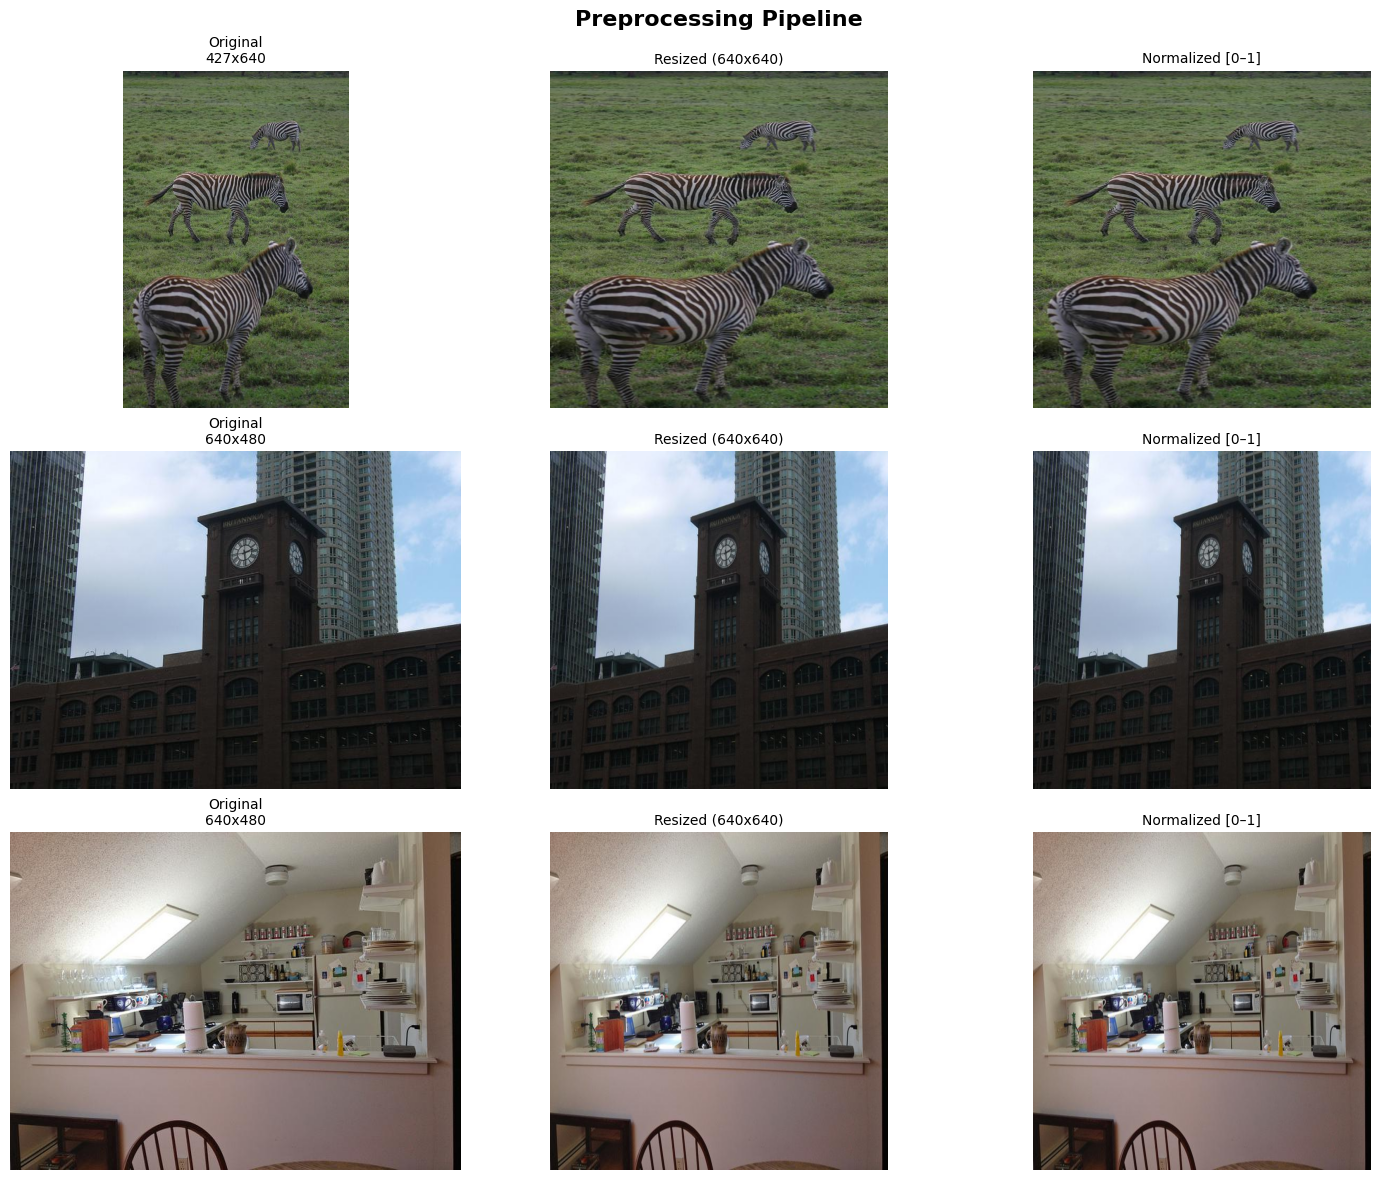

✅ Preprocessing visualization saved!


In [11]:

def preprocess_image(img_path, target_size=(640, 640)):
    """Resize and normalize an image."""
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img_resized = cv2.resize(img_rgb, target_size)

    # Normalize to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_rgb, img_resized, img_normalized

# Pick 3 random samples
sample_imgs = random.sample(image_files, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Preprocessing Pipeline", fontsize=16, fontweight='bold')

for i, img_path in enumerate(sample_imgs):
    original, resized, normalized = preprocess_image(img_path)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original\n{original.shape[1]}x{original.shape[0]}", fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(resized)
    axes[i, 1].set_title("Resized (640x640)", fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(normalized)
    axes[i, 2].set_title("Normalized [0–1]", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig("preprocessing_pipeline.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessing visualization saved!")

 Found 128 label files in COCO128


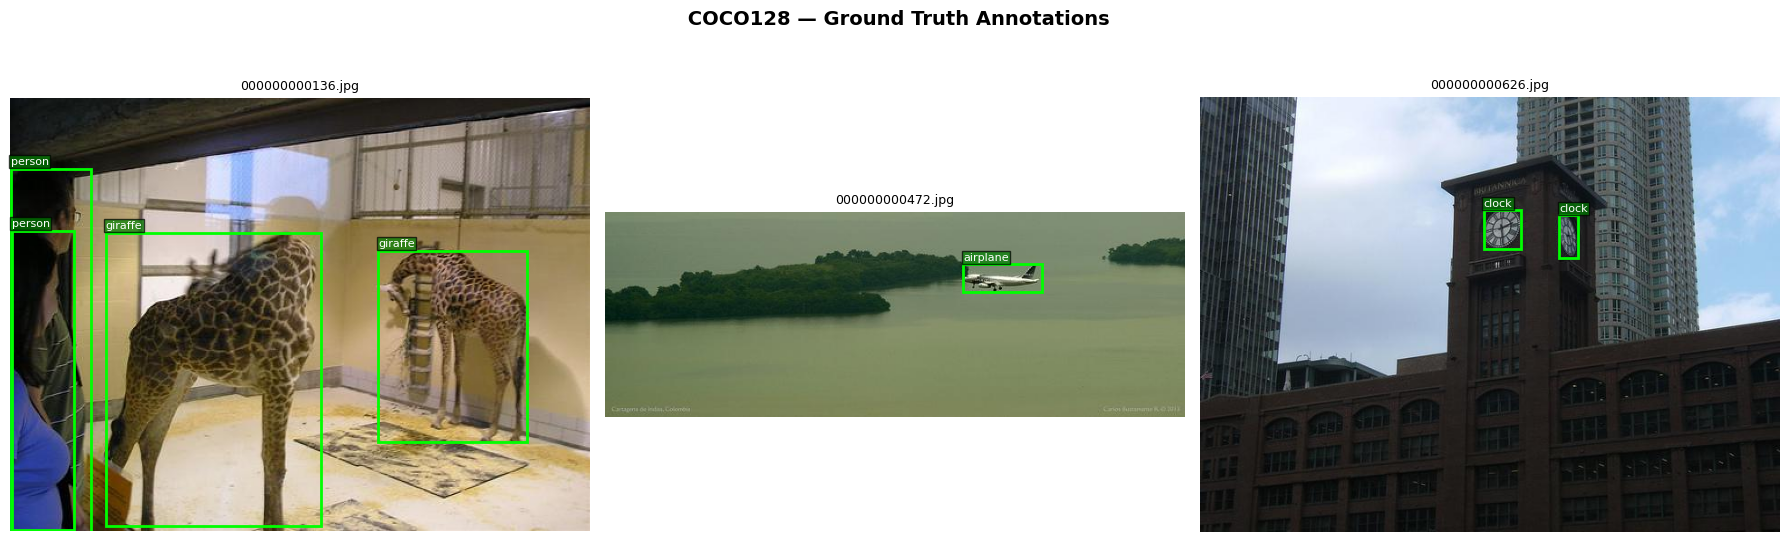

✅ COCO128 annotation visualization done!


In [12]:

class_names = dataset_info['names']
label_dir   = str(Path(dataset_path) / "labels" / "train2017")
label_files = glob.glob(label_dir + "/*.txt")

print(f" Found {len(label_files)} label files in COCO128")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(" COCO128 — Ground Truth Annotations", fontsize=14, fontweight='bold')

for i in range(3):
    lbl = random.choice(label_files)
    img_name = os.path.basename(lbl).replace('.txt', '.jpg')
    img_p    = str(Path(dataset_path) / "images" / "train2017" / img_name)
    img      = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
    h, w     = img.shape[:2]
    axes[i].imshow(img)

    with open(lbl) as f:
        for line in f:
            p = line.strip().split()
            cls_id = int(p[0])
            cx, cy, bw, bh = float(p[1]), float(p[2]), float(p[3]), float(p[4])
            x1 = (cx - bw/2)*w
            y1 = (cy - bh/2)*h
            rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                      linewidth=2, edgecolor='lime', facecolor='none')
            axes[i].add_patch(rect)
            axes[i].text(x1, y1-4, class_names.get(cls_id, str(cls_id)),
                         fontsize=8, color='white',
                         bbox=dict(facecolor='green', alpha=0.7, pad=1))

    axes[i].set_title(img_name, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("annotations_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ COCO128 annotation visualization done!")

In [13]:

from ultralytics import YOLO

# Load YOLOv8n (nano) — fastest; change to yolov8s/m/l for better accuracy
model = YOLO("yolov8n.pt")

print("✅ YOLOv8n pretrained model loaded!")
print(f"\n Model Architecture Summary:")
model.info()

✅ YOLOv8n pretrained model loaded!

 Model Architecture Summary:
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [7]:

# Hyperparameters: lr=0.01 | batch=16 | epochs=10
model = YOLO("yolov8n.pt")

results_exp1 = model.train(
    data="coco128.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    lr0=0.01,
    name="exp1_lr001_bs16",
    exist_ok=True,
    verbose=True
)

print("\n✅ Experiment 1 done!")
print("   LR=0.01 | Batch=16 | Epochs=10")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_lr001_bs16, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

In [14]:

# Hyperparameters: lr=0.001 | batch=8 | epochs=10
model2 = YOLO("yolov8n.pt")

results_exp2 = model2.train(
    data="coco128.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    lr0=0.001,
    name="exp2_lr0001_bs8",
    exist_ok=True,
    verbose=True
)

print("\n✅ Experiment 2 done!")
print("   LR=0.001 | Batch=8 | Epochs=10")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_lr0001_bs8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

In [15]:

# Hyperparameters: lr=0.005 | batch=32 | epochs=20
model3 = YOLO("yolov8n.pt")

results_exp3 = model3.train(
    data="coco128.yaml",
    epochs=20,
    imgsz=640,
    batch=32,
    lr0=0.005,
    name="exp3_lr0005_bs32_ep20",
    exist_ok=True,
    verbose=True
)

print("\n✅ Experiment 3 done!")
print("   LR=0.005 | Batch=32 | Epochs=20")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_lr0005_bs32_ep20, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

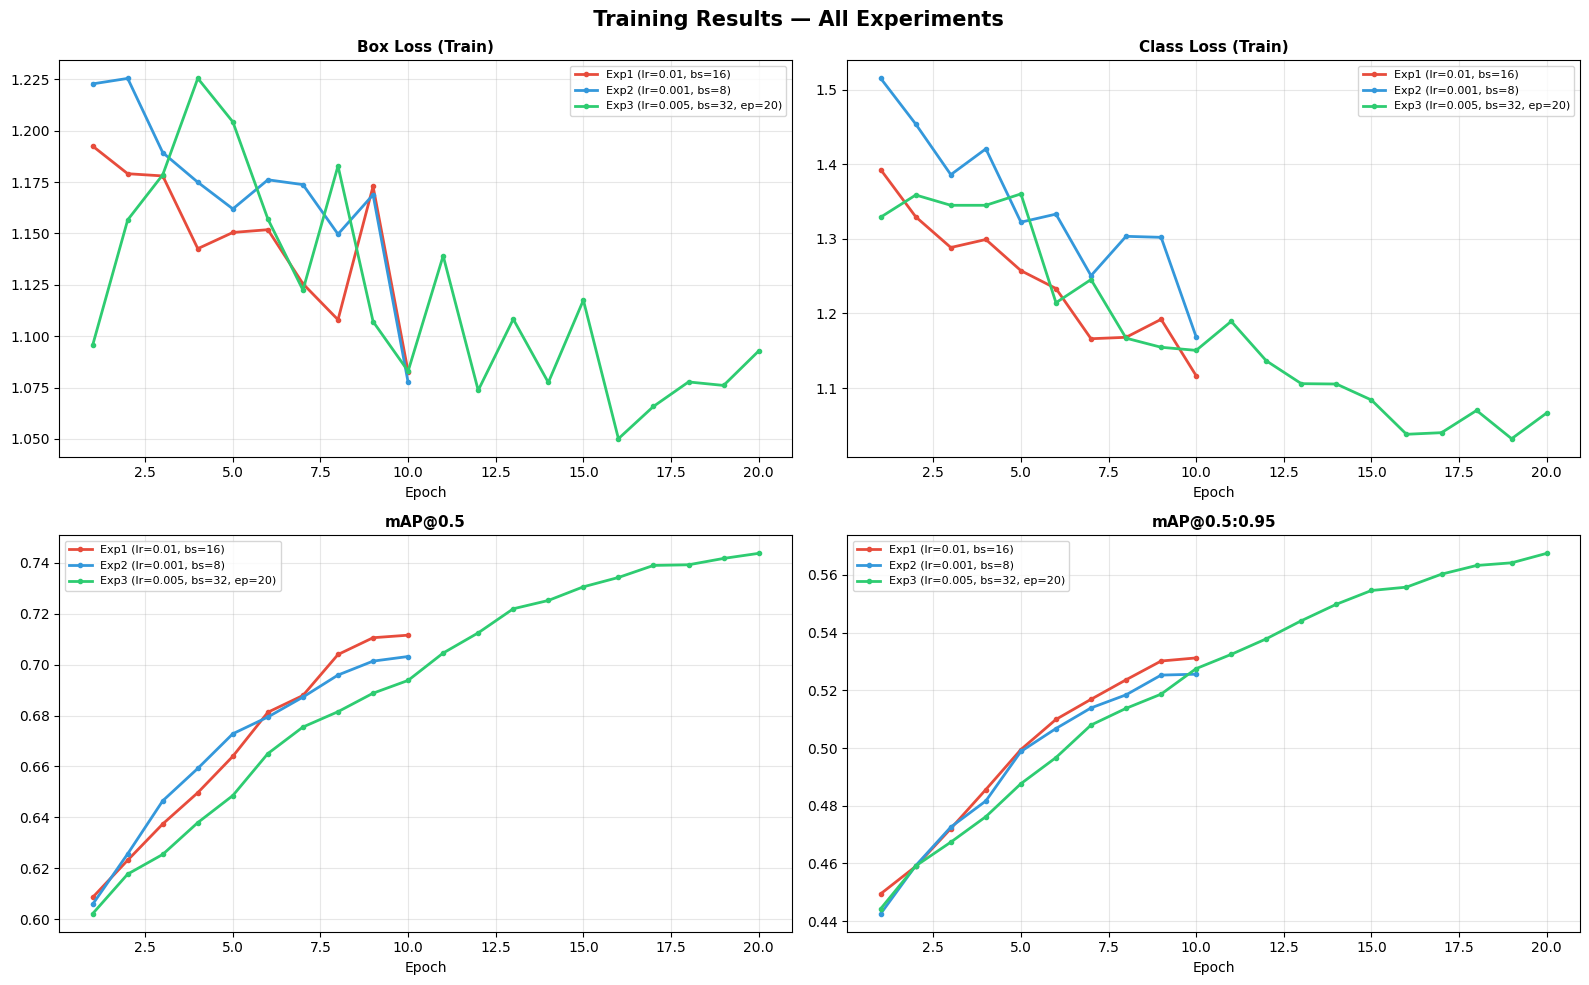

✅ Training curves saved!


In [16]:

import pandas as pd

exp_dirs = {
    "Exp1 (lr=0.01, bs=16)":  "runs/detect/exp1_lr001_bs16/results.csv",
    "Exp2 (lr=0.001, bs=8)":  "runs/detect/exp2_lr0001_bs8/results.csv",
    "Exp3 (lr=0.005, bs=32, ep=20)": "runs/detect/exp3_lr0005_bs32_ep20/results.csv",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(" Training Results — All Experiments", fontsize=15, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71']
metrics = {
    (0,0): ("train/box_loss",   "Box Loss (Train)"),
    (0,1): ("train/cls_loss",   "Class Loss (Train)"),
    (1,0): ("metrics/mAP50(B)", "mAP@0.5"),
    (1,1): ("metrics/mAP50-95(B)", "mAP@0.5:0.95"),
}

for (r, c), (col, title) in metrics.items():
    ax = axes[r][c]
    for (label, csv_path), color in zip(exp_dirs.items(), colors):
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()
            if col in df.columns:
                ax.plot(df['epoch'], df[col], label=label, color=color, linewidth=2, marker='o', markersize=3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved!")

In [17]:

best_models = {
    "Exp1 (lr=0.01,  bs=16,  ep=10)":  "runs/detect/exp1_lr001_bs16/weights/best.pt",
    "Exp2 (lr=0.001, bs=8,   ep=10)":  "runs/detect/exp2_lr0001_bs8/weights/best.pt",
    "Exp3 (lr=0.005, bs=32,  ep=20)":  "runs/detect/exp3_lr0005_bs32_ep20/weights/best.pt",
}

eval_results = {}

for name, weight_path in best_models.items():
    if os.path.exists(weight_path):
        m = YOLO(weight_path)
        val_res = m.val(data="coco128.yaml", verbose=False)
        eval_results[name] = {
            "mAP@0.5":      round(val_res.box.map50, 4),
            "mAP@0.5:0.95": round(val_res.box.map,   4),
            "Precision":    round(val_res.box.mp,     4),
            "Recall":       round(val_res.box.mr,     4),
        }
        print(f"\n✅ {name}")
        for k, v in eval_results[name].items():
            print(f"   {k}: {v}")
    else:
        print(f" Weight not found: {weight_path}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2484.6±771.4 MB/s, size: 53.4 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 48.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.3it/s 3.5s
                   all        128        929      0.706      0.661      0.712      0.532
Speed: 4.7ms preprocess, 7.3ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val

✅ Exp1 (lr=0.01,  bs=16,  ep=10)
   mAP@0.5: 0.712
   mAP@0.5:0.95: 0.5322
   Precision: 0.7057
   Recall: 0.6612
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7


 Metrics Comparison Table:
                                mAP@0.5  mAP@0.5:0.95  Precision  Recall
Exp1 (lr=0.01,  bs=16,  ep=10)   0.7120        0.5322     0.7057  0.6612
Exp2 (lr=0.001, bs=8,   ep=10)   0.7041        0.5250     0.6605  0.6918
Exp3 (lr=0.005, bs=32,  ep=20)   0.7412        0.5682     0.7804  0.6477


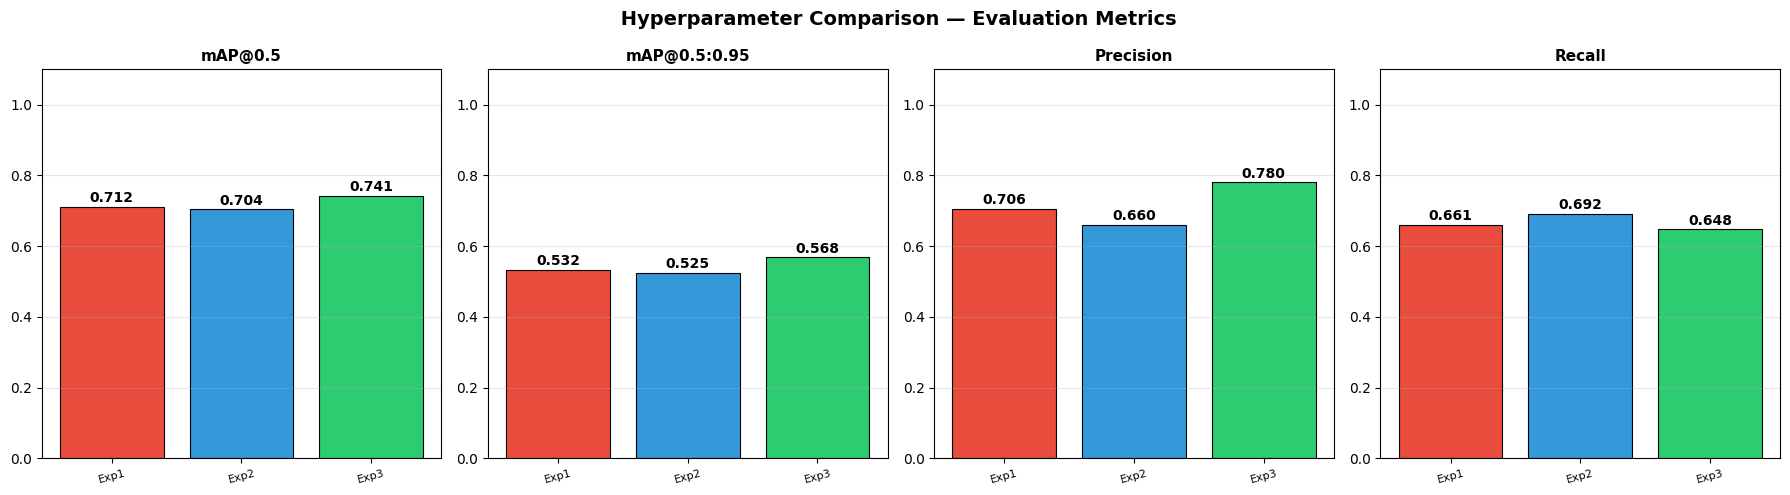

✅ Metrics comparison chart saved!


In [18]:

results_df = pd.DataFrame(eval_results).T
print("\n Metrics Comparison Table:")
print(results_df.to_string())

# Bar chart
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(" Hyperparameter Comparison — Evaluation Metrics", fontsize=14, fontweight='bold')

metrics_list = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall"]
colors_bar   = ['#e74c3c', '#3498db', '#2ecc71']
exp_labels   = [e.split('(')[0].strip() for e in results_df.index]

for ax, metric in zip(axes, metrics_list):
    vals = results_df[metric].values
    bars = ax.bar(exp_labels, vals, color=colors_bar[:len(vals)], edgecolor='black', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(exp_labels, rotation=15, fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics comparison chart saved!")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1741.7±882.0 MB/s, size: 63.6 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 59.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7it/s 3.0s
                   all        128        929      0.692      0.663      0.675      0.516
Speed: 3.1ms preprocess, 4.3ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val-4
  conf=0.10 → P=0.692  R=0.663  mAP50=0.675
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1990.6±970.9 MB/s, size: 50.8 KB)
val: Scanning /content/datasets/coco128/labels/train2017.

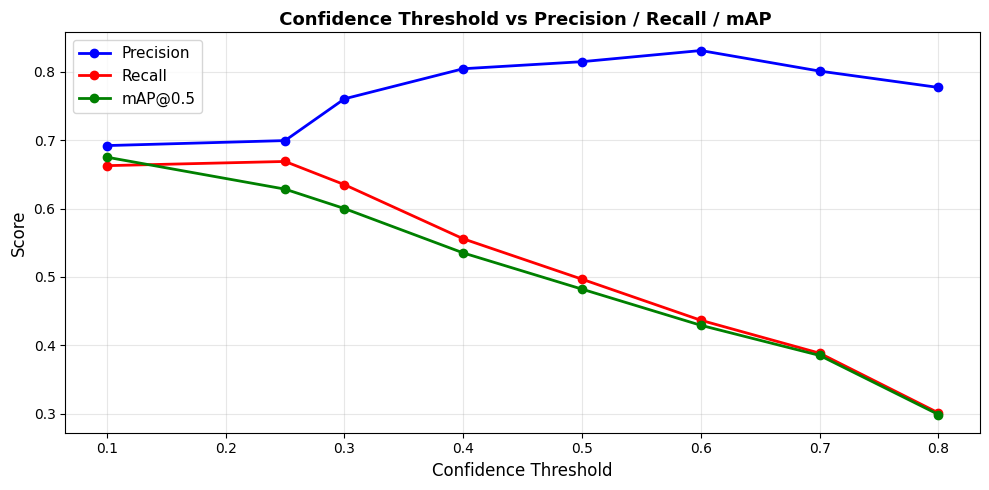

✅ Confidence threshold analysis saved!


In [19]:

best_model_path = "runs/detect/exp1_lr001_bs16/weights/best.pt"
best_m = YOLO(best_model_path)

thresholds = [0.1, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
precisions, recalls, maps = [], [], []

for thresh in thresholds:
    r = best_m.val(data="coco128.yaml", conf=thresh, verbose=False)
    precisions.append(r.box.mp)
    recalls.append(r.box.mr)
    maps.append(r.box.map50)
    print(f"  conf={thresh:.2f} → P={r.box.mp:.3f}  R={r.box.mr:.3f}  mAP50={r.box.map50:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, 'b-o', label='Precision', linewidth=2)
ax.plot(thresholds, recalls,    'r-o', label='Recall',    linewidth=2)
ax.plot(thresholds, maps,       'g-o', label='mAP@0.5',  linewidth=2)
ax.set_xlabel("Confidence Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(" Confidence Threshold vs Precision / Recall / mAP", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_threshold_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confidence threshold analysis saved!")

In [20]:

test_images = random.sample(image_files, 9)

best_m = YOLO("runs/detect/exp1_lr001_bs16/weights/best.pt")

predictions = best_m.predict(
    source=test_images,
    conf=0.25,
    iou=0.45,
    save=False,
    verbose=False
)

print(f"✅ Predictions done on {len(predictions)} images!")
for i, r in enumerate(predictions[:3]):
    print(f"\n  Image {i+1}: {os.path.basename(r.path)}")
    print(f"    Detected objects: {len(r.boxes)}")
    if len(r.boxes) > 0:
        for box in r.boxes[:5]:
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            print(f"      → {class_names[cls_id]} (conf={conf:.2f})")

✅ Predictions done on 9 images!

  Image 1: image0.jpg
    Detected objects: 1
      → pizza (conf=0.75)

  Image 2: image1.jpg
    Detected objects: 2
      → wine glass (conf=0.91)
      → person (conf=0.70)

  Image 3: image2.jpg
    Detected objects: 7
      → bottle (conf=0.63)
      → bottle (conf=0.62)
      → sandwich (conf=0.37)
      → banana (conf=0.36)
      → cake (conf=0.34)


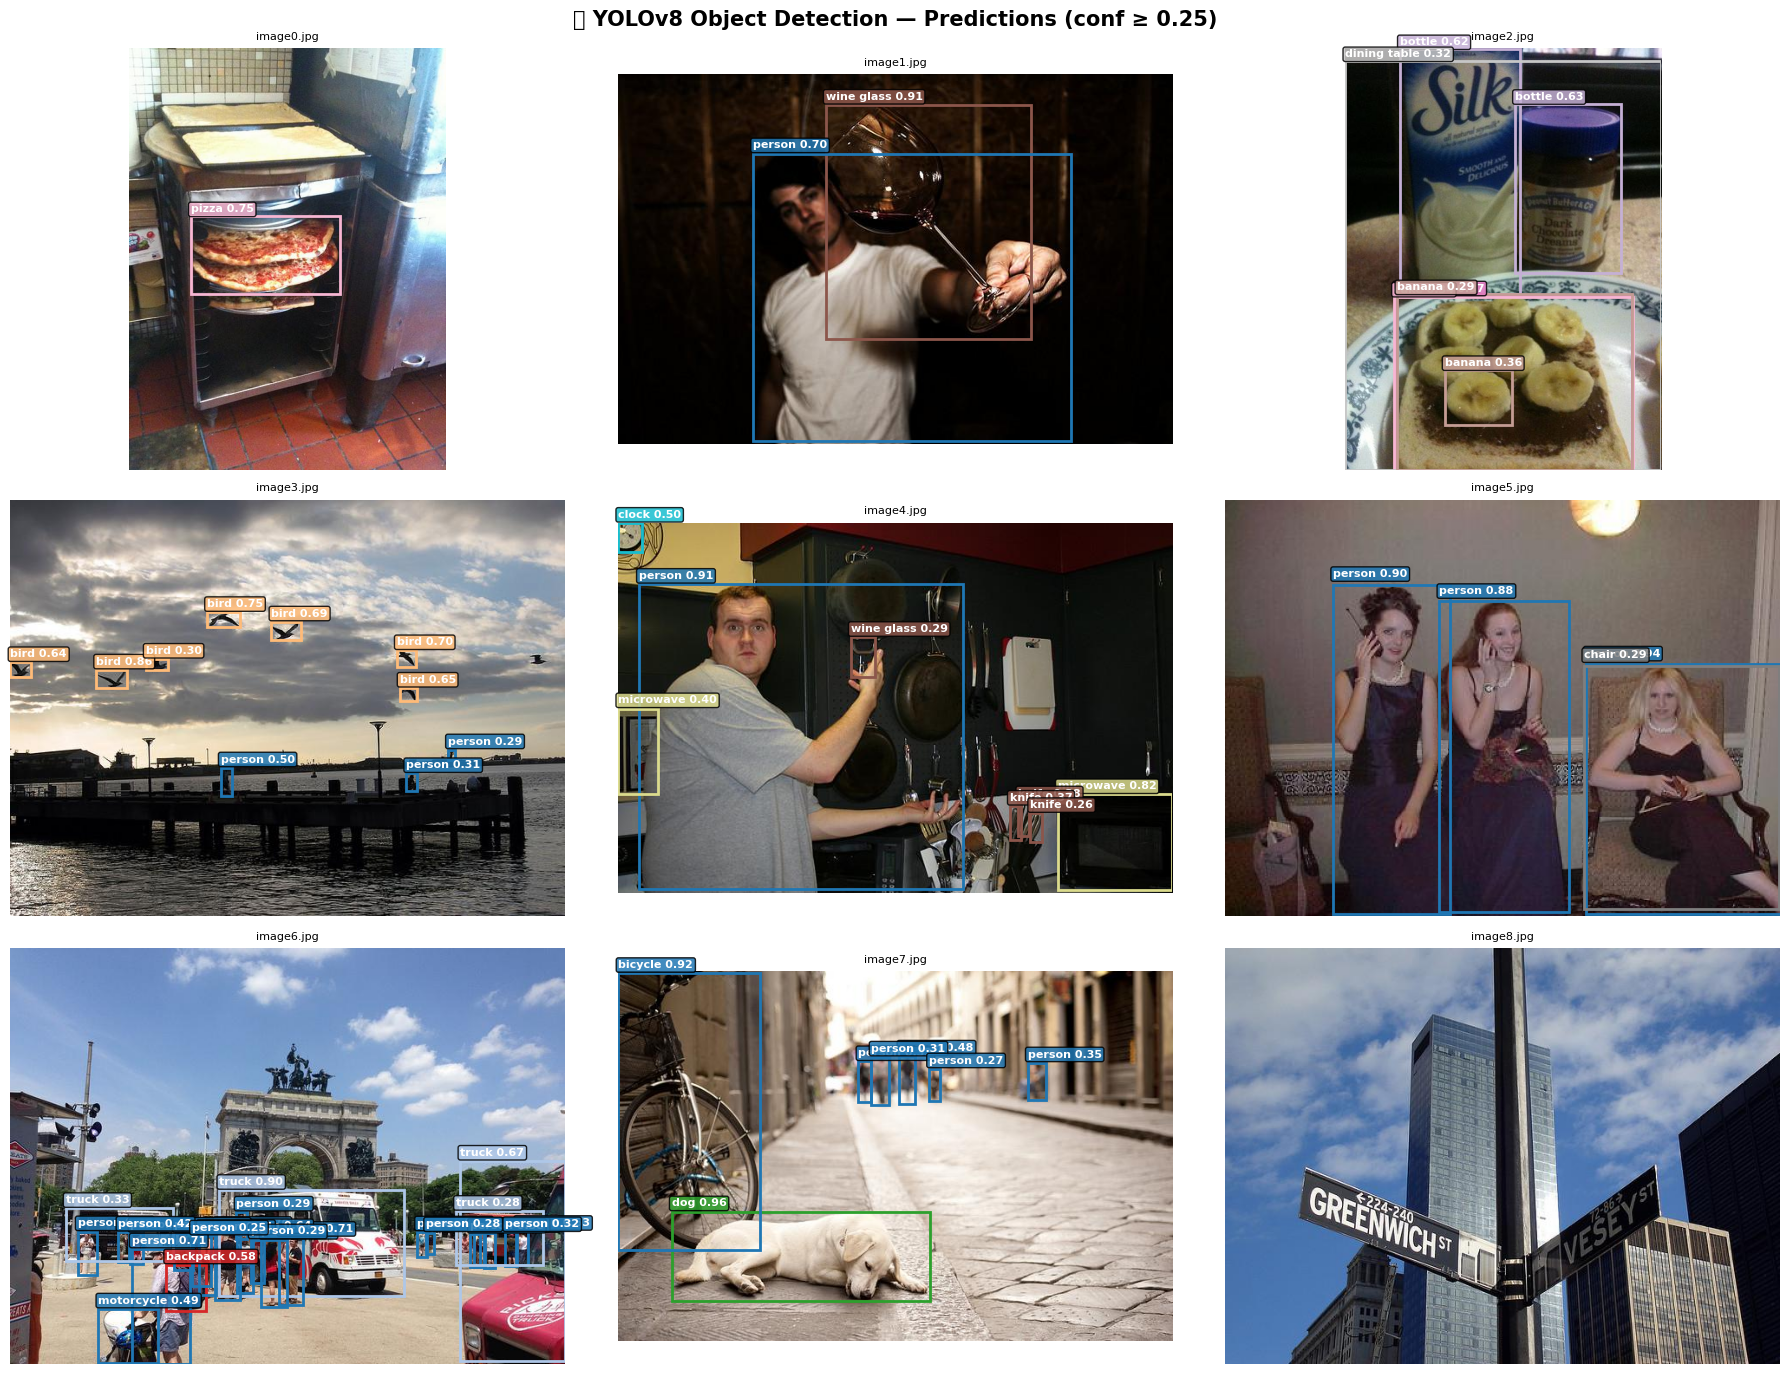

✅ Detection visualization saved!


In [21]:

def draw_predictions(result, class_names, ax):
    img = result.orig_img
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    if result.boxes is not None and len(result.boxes) > 0:
        palette = plt.cm.tab20(np.linspace(0, 1, 80))

        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            label  = f"{class_names.get(cls_id, str(cls_id))} {conf:.2f}"
            color  = palette[cls_id % 80]

            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 6, label,
                    fontsize=8, color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))

    ax.set_title(os.path.basename(result.path), fontsize=8)
    ax.axis('off')


fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("🔍 YOLOv8 Object Detection — Predictions (conf ≥ 0.25)", fontsize=15, fontweight='bold')

for ax, result in zip(axes.flatten(), predictions):
    draw_predictions(result, class_names, ax)

plt.tight_layout()
plt.savefig("detection_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Detection visualization saved!")

In [22]:

print("=" * 65)
print("      DEEP LEARNING OBJECT DETECTION — PROJECT SUMMARY")
print("=" * 65)

print("\n Dataset : COCO128 (128 images, 80 classes)")
print(" Model   : YOLOv8n (pretrained on COCO)")
print(" Preprocessing : Resize 640×640 · Normalize [0,1] · YOLO annotations")

print("\n┌──────────────────────────────┬────────┬───────┬───────────┐")
print("│ Experiment                   │ LR     │ Batch │ Epochs    │")
print("├──────────────────────────────┼────────┼───────┼───────────┤")
print("│ Exp1                         │ 0.01   │ 16    │ 10        │")
print("│ Exp2                         │ 0.001  │ 8     │ 10        │")
print("│ Exp3                         │ 0.005  │ 32    │ 20        │")
print("└──────────────────────────────┴────────┴───────┴───────────┘")

print("\n Evaluation Metrics (best model per experiment):")
if eval_results:
    print(f"\n{'Experiment':<35} {'mAP@0.5':>9} {'mAP50-95':>9} {'Precision':>10} {'Recall':>8}")
    print("-" * 75)
    for exp, m in eval_results.items():
        print(f"{exp:<35} {m['mAP@0.5']:>9.4f} {m['mAP@0.5:0.95']:>9.4f} {m['Precision']:>10.4f} {m['Recall']:>8.4f}")

print("\n Saved Files:")
saved = ["preprocessing_pipeline.png", "annotations_preview.png",
         "training_curves.png", "metrics_comparison.png",
         "confidence_threshold_analysis.png", "detection_predictions.png"]
for f in saved:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"   {exists} {f}")

print("\n" + "=" * 65)
print("✅ Project complete!")

      DEEP LEARNING OBJECT DETECTION — PROJECT SUMMARY

 Dataset : COCO128 (128 images, 80 classes)
 Model   : YOLOv8n (pretrained on COCO)
 Preprocessing : Resize 640×640 · Normalize [0,1] · YOLO annotations

┌──────────────────────────────┬────────┬───────┬───────────┐
│ Experiment                   │ LR     │ Batch │ Epochs    │
├──────────────────────────────┼────────┼───────┼───────────┤
│ Exp1                         │ 0.01   │ 16    │ 10        │
│ Exp2                         │ 0.001  │ 8     │ 10        │
│ Exp3                         │ 0.005  │ 32    │ 20        │
└──────────────────────────────┴────────┴───────┴───────────┘

 Evaluation Metrics (best model per experiment):

Experiment                            mAP@0.5  mAP50-95  Precision   Recall
---------------------------------------------------------------------------
Exp1 (lr=0.01,  bs=16,  ep=10)         0.7120    0.5322     0.7057   0.6612
Exp2 (lr=0.001, bs=8,   ep=10)         0.7041    0.5250     0.6605   0.6918
E